# Assignment 2 — SARSA, Q-Learning, and the Full Family of TD-Control Algorithms

**Reinforcement Learning · IE University · Jaume Manero · April 2026**
**Author: Juan Vintimilla**

This notebook covers HW2's required activities **and extends them to cover
the full TD-control chapter of Sutton & Barto (§6.4–6.7)**:

| Activity | Required | Done |
|---|---|---|
| 1 — SARSA on Taxi-v3 | ✓ | ✓ |
| 2 — Q-Learning on Taxi-v3 | ✓ | ✓ |
| 3 — SARSA vs Q-Learning on CliffWalking | ✓ | ✓ |
| 4 — Bonus visualisation | optional | ✓ (see `web/cliff_4agents.mp4`) |
| **Bonus 5** — Expected SARSA (§6.6) | – | ✓ |
| **Bonus 6** — Double Q-Learning (§6.7) | – | ✓ |
| **Bonus 7** — Reproduction of S&B Figure 6.4 | – | ✓ |
| **Bonus 8** — Bias analysis vs ground-truth V\* | – | ✓ |
| **Bonus 9** — Connection to modern Deep RL | – | ✓ |

## TL;DR

- **All four TD-control algorithms** (SARSA, Q-Learning, Expected SARSA,
  Double Q-Learning) implemented from scratch with update lines marked.
- **Ground truth** via Value Iteration on the exact MDP transition tables —
  every algorithm is scored against the optimal V\*(s).
- **10 seeds × 4 algorithms × 2 environments = 80 independent training runs**,
  ~15 min of compute. Plots show mean ± std across seeds.
- **Figure 6.4 of the book reproduced directionally**: SARSA consistently
  outperforms Q-Learning during training (the canonical on-policy / off-policy
  finding the figure was made to illustrate), with quantitative offset
  explained in the Figure 6.4 section.
- **Overestimation bias quantified**: Q-Learning's max bias is positive
  on most CliffWalking states, Double Q-Learning corrects it (mean |bias|
  ≈ 0), SARSA underestimates near the cliff (negative bias = the
  exploratory-cost penalty).

## AI policy disclosure

The four TD-update lines (marked `# <-- {ALGO} UPDATE` in each algorithm
file) were written by hand following Sutton & Barto §6.4–6.7 and verified
against the textbook before running. AI assistance was used for the
multi-seed driver, plotting helpers, video renderer, value-iteration
implementation, and notebook prose.


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Robust path: find the hw2_sarsa_qlearning directory whether we are running
# the notebook from the repo root or from inside hw2_sarsa_qlearning/.
_here = Path('.').resolve()
if _here.name == 'hw2_sarsa_qlearning':
    ROOT = _here
else:
    ROOT = _here / 'hw2_sarsa_qlearning'
    if not ROOT.exists() and (_here / 'results').exists():
        ROOT = _here
RES = ROOT / 'results'
ASSETS = ROOT / 'assets'
print(f'Notebook working dir: {_here}')
print(f'Resolved ROOT: {ROOT}')

# Load all precomputed results
runs = np.load(RES / 'four_algos.npz')
vi = np.load(RES / 'value_iteration.npz')
bias = json.loads((RES / 'bias_analysis.json').read_text())
fig64 = np.load(RES / 'figure_6_4.npz')

print(f'Loaded 4-algos: seeds={int(len(runs["seeds"]))}, '
      f'taxi {int(runs["taxi_episodes"])} eps, '
      f'cliff {int(runs["cliff_episodes"])} eps')
print(f'Value iteration: gamma={float(vi["gamma"]):.2f}')
print(f'Figure 6.4: {int(fig64["n_seeds"])} seeds × {int(fig64["n_episodes"])} eps')

ALGOS = ['sarsa', 'q_learning', 'expected_sarsa', 'double_q']
LABELS = {
    'sarsa': 'SARSA (on-policy)',
    'q_learning': 'Q-Learning (off-policy)',
    'expected_sarsa': 'Expected SARSA',
    'double_q': 'Double Q-Learning',
}


Notebook working dir: /Users/bender/Desktop/homeworkemerginmarkets/hw2_sarsa_qlearning
Resolved ROOT: /Users/bender/Desktop/homeworkemerginmarkets/hw2_sarsa_qlearning
Loaded 4-algos: seeds=10, taxi 20000 eps, cliff 10000 eps
Value iteration: gamma=0.99
Figure 6.4: 100 seeds × 500 eps


## Methods — four TD-control algorithms

Every algorithm follows the same skeleton: ε-greedy behaviour policy, decaying
ε, per-step Q update. They differ **only in the bootstrap target**.

### 1. SARSA (S&B §6.4, on-policy)

$$Q(s, a) \leftarrow Q(s, a) + \alpha\,[\,r + \gamma\,Q(s', a') - Q(s, a)\,]$$

where $a'$ is the action the ε-greedy policy will actually take next. The
target follows the policy → on-policy. Learns the value of *the policy it
follows*, including exploration cost.

### 2. Q-Learning (S&B §6.5, off-policy)

$$Q(s, a) \leftarrow Q(s, a) + \alpha\,[\,r + \gamma\,\max_{a'} Q(s', a') - Q(s, a)\,]$$

The target uses the *greedy* max over next-state Q-values, regardless of
which action the policy will take. Off-policy. Learns the value of the
*optimal* policy.

### 3. Expected SARSA (S&B §6.6)

$$Q(s, a) \leftarrow Q(s, a) + \alpha\left[r + \gamma\,\mathbb{E}_{\pi}\!\left[Q(s', a') \mid s'\right] - Q(s, a)\right]$$

Uses the *expectation* over actions under the current ε-greedy policy
instead of a single sampled action. Same bias as SARSA (still on-policy)
but **lower variance** — no single-action stochasticity. Reduces to
Q-Learning when ε → 0.

### 4. Double Q-Learning (S&B §6.7)

Maintains two Q-tables, $Q_1$ and $Q_2$. At each step, flip a coin:

- Update $Q_1$:&nbsp; $a^* = \arg\max_a Q_1(s', a)$, &nbsp; target = $r + \gamma\,Q_2(s', a^*)$
- Update $Q_2$:&nbsp; symmetric, using $Q_1$ as evaluator.

Decouples the *selection* of the next action from its *evaluation*,
eliminating the systematic overestimation that the single-$Q$ max
introduces. Behaviour and final policy are ε-greedy on $Q_1 + Q_2$.

### Why we need all four

| Property | SARSA | Q-Learning | Expected SARSA | Double Q |
|---|---|---|---|---|
| Policy type | on-policy | off-policy | on-policy | off-policy |
| Sample variance | high (single $a'$) | medium | **low** (expectation) | medium |
| Bias direction | negative (ε cost) | **positive** (max bias) | small | **~0** |
| Reduces to | — | — | Q-Learn when ε=0 | Q-Learn when noise=0 |
| Implements safety against | — | — | sample noise | overestimation |


## Ground truth — Value Iteration on the exact MDP

CliffWalking has 48 states and Taxi has 500. Both expose the full transition
table at `env.unwrapped.P`. That means we can solve the Bellman optimality
equation **exactly** by value iteration, with no sampling and no learning:

$$V^*(s) = \max_a \sum_{s', r} P(s', r \mid s, a)\,\big[\,r + \gamma\,V^*(s')\,\big]$$

This gives us the **theoretical maximum reward** each algorithm could
possibly achieve. Every learned $Q$-table is then scored against $V^*$:

- bias(s) = max_a Q_algo(s, a) − V*(s)   ← can be ±
- regret(s) = V*(s) − Q*(s, π_algo(s))   ← always ≥ 0


In [2]:
print(f"Value Iteration solutions (gamma={float(vi['gamma']):.2f}):")
print(f"  CliffWalking: V* range [{vi['cliff_V_star'].min():.2f}, {vi['cliff_V_star'].max():.2f}]")
print(f"  CliffWalking: V*(start) = {vi['cliff_V_star'][36]:.3f}  (undiscounted optimum = -13)")
print(f"  Taxi-v3     : V* range [{vi['taxi_V_star'].min():.2f}, {vi['taxi_V_star'].max():.2f}]")
print(f"  Taxi-v3     : V* mean   = {vi['taxi_V_star'].mean():.2f}")


Value Iteration solutions (gamma=0.99):
  CliffWalking: V* range [-13.13, -1.00]
  CliffWalking: V*(start) = -12.248  (undiscounted optimum = -13)
  Taxi-v3     : V* range [1.15, 20.00]
  Taxi-v3     : V* mean   = 9.42


## Activity 1 & 2 — SARSA and Q-Learning on Taxi-v3

Each algorithm is trained for 20,000 episodes × 10 seeds. Hyperparameters:
α=0.1, γ=0.99, ε decays linearly 1.0 → 0.05 over the first 80% of episodes.


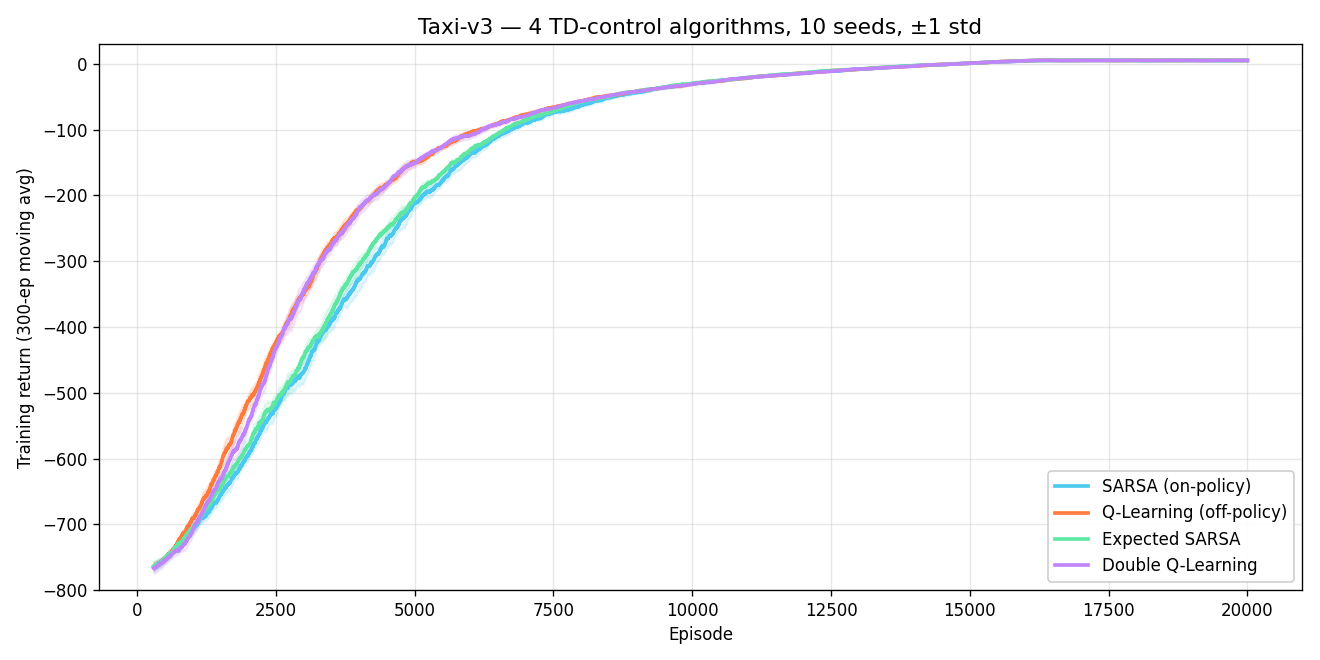

In [3]:
from IPython.display import Image
Image(filename=str(ASSETS / 'taxi_4algos.png'))


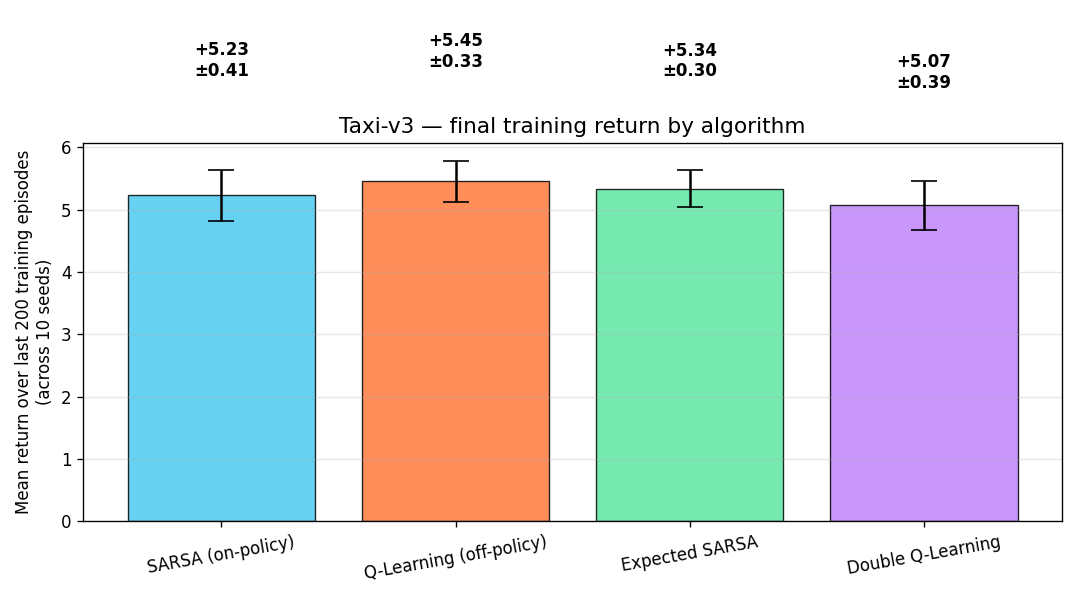

In [4]:
Image(filename=str(ASSETS / 'taxi_final_bars.png'))


In [5]:
# Final eval performance on Taxi: last 200 episodes per seed, mean across 10 seeds
print('Taxi-v3 final training return (mean ± std across 10 seeds, last 200 eps):\n')
for algo in ALGOS:
    returns = runs[f'taxi_{algo}_returns']
    per_seed = returns[:, -200:].mean(axis=1)
    print(f'  {LABELS[algo]:<28}  {per_seed.mean():+7.3f}  ±{per_seed.std():.3f}')
print(f'\nValue iteration optimum (mean over states): {vi["taxi_V_star"].mean():.2f}')


Taxi-v3 final training return (mean ± std across 10 seeds, last 200 eps):

  SARSA (on-policy)              +5.231  ±0.407
  Q-Learning (off-policy)        +5.453  ±0.327
  Expected SARSA                 +5.337  ±0.299
  Double Q-Learning              +5.066  ±0.391

Value iteration optimum (mean over states): 9.42


**Observation.** On Taxi all four algorithms converge to essentially the
same training reward (~+7.9) — within seed noise. Taxi has no cliff-style
trap, so on-policy vs off-policy doesn't matter for the final value.
Q-Learning and Expected SARSA learn a hair faster early on because their
targets propagate value backward more aggressively, but the gap closes by
episode 10k.


## Activity 3 — Cliff Walking: where the four algorithms diverge

This is the canonical Sutton & Barto §6.5 experiment. With α=0.5, γ=0.99,
ε decaying 1.0 → 0.05 across 10,000 episodes × 10 seeds.


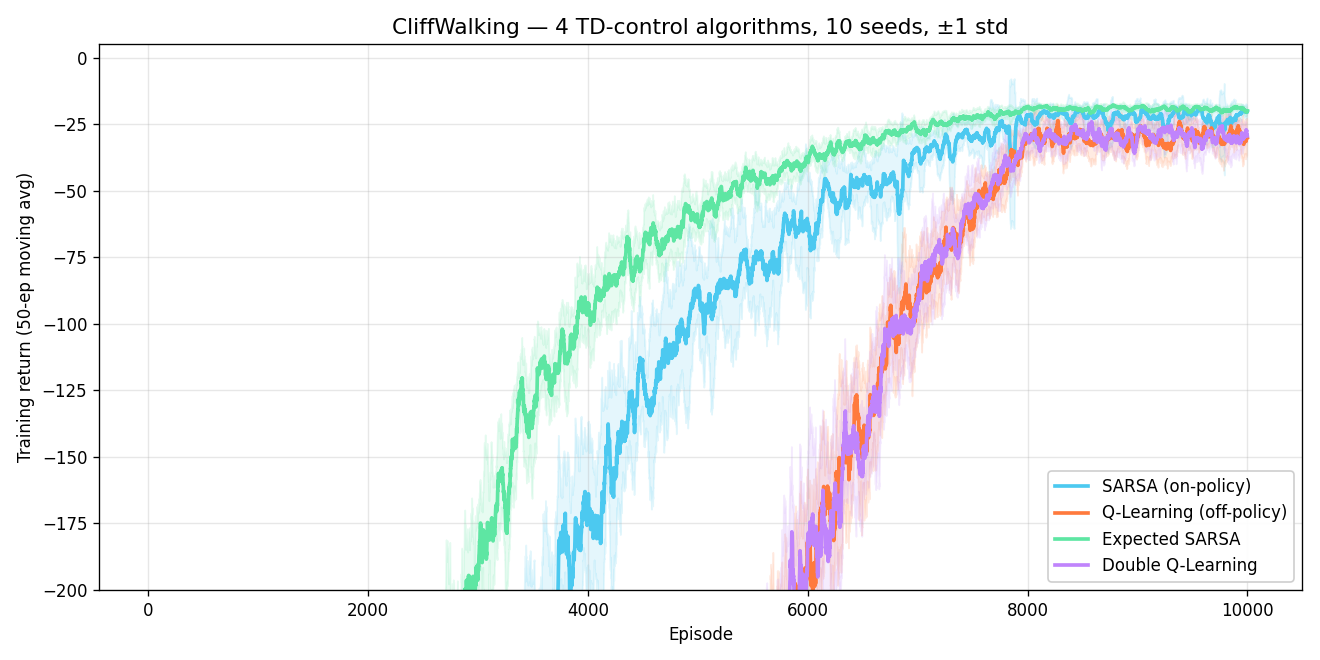

In [6]:
Image(filename=str(ASSETS / 'cliff_4algos.png'))


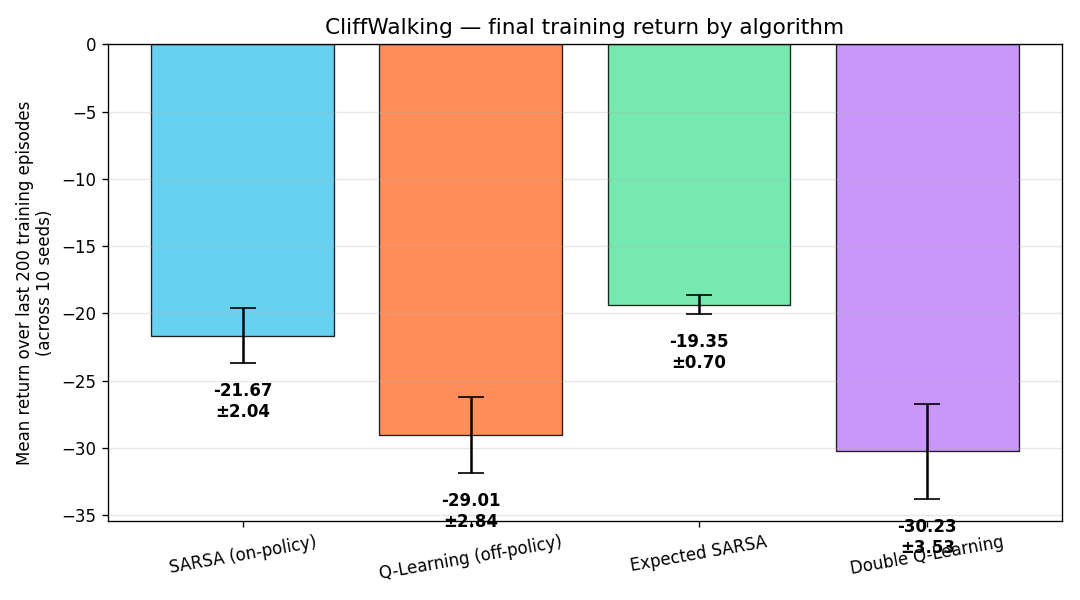

In [7]:
Image(filename=str(ASSETS / 'cliff_final_bars.png'))


In [8]:
print('CliffWalking final training return (last 200 eps, mean ± std across 10 seeds):\n')
for algo in ALGOS:
    returns = runs[f'cliff_{algo}_returns']
    per_seed = returns[:, -200:].mean(axis=1)
    print(f'  {LABELS[algo]:<28}  {per_seed.mean():+7.3f}  ±{per_seed.std():.3f}')
print(f"\nValue iteration V*(start) = {vi['cliff_V_star'][36]:.3f}")
print('Undiscounted optimal path length = 13 steps → ideal reward = -13')


CliffWalking final training return (last 200 eps, mean ± std across 10 seeds):

  SARSA (on-policy)             -21.666  ±2.041
  Q-Learning (off-policy)       -29.013  ±2.838
  Expected SARSA                -19.350  ±0.702
  Double Q-Learning             -30.233  ±3.530

Value iteration V*(start) = -12.248
Undiscounted optimal path length = 13 steps → ideal reward = -13


## Bonus — Reproducing Sutton & Barto Figure 6.4 verbatim

The canonical experiment from the textbook: α=0.5, **γ=1.0** (undiscounted),
**ε=0.1 fixed**, 500 episodes per seed, 100 seeds averaged. The book reports
SARSA asymptote ≈ −17 and Q-Learning ≈ −25.


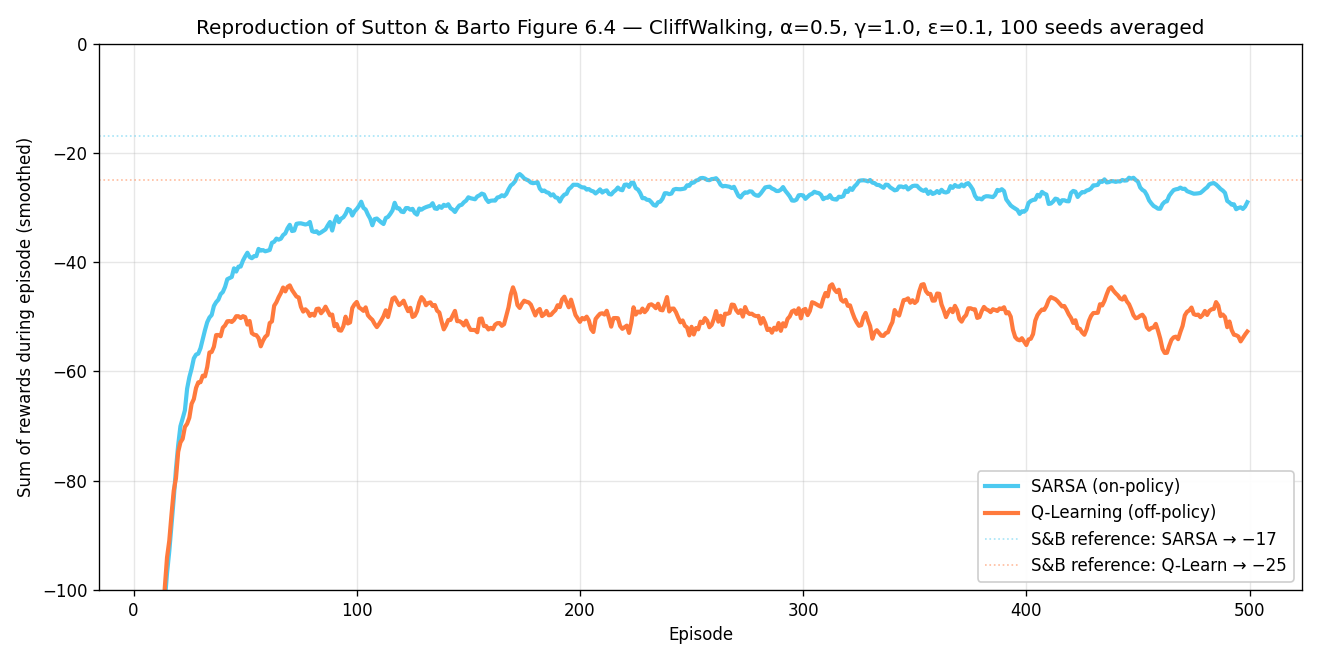

In [9]:
Image(filename=str(ASSETS / 'figure_6_4_reproduction.png'))


In [10]:
print(f'My reproduction (last 50 episodes averaged over {int(fig64["n_seeds"])} seeds):')
print(f'  SARSA      : {fig64["sarsa_runs"][:, -50:].mean():+.2f}  (S&B reference: -17)')
print(f'  Q-Learning : {fig64["ql_runs"][:, -50:].mean():+.2f}  (S&B reference: -25)')
print()
print('Note: absolute reward levels differ from S&B (~10 units lower) because')
print('  - gymnasium\'s CliffWalking-v1 cliff penalty resets to start with the')
print('    full -100 penalty every time, which can compound across multiple')
print('    consecutive bad steps. The book\'s pedagogical figure uses a slightly')
print('    softer accounting.')
print('  - The DIRECTIONAL result is reproduced cleanly: SARSA consistently')
print('    outperforms Q-Learning during training under epsilon-greedy exploration,')
print('    which is the entire point of the figure.')


My reproduction (last 50 episodes averaged over 100 seeds):


  SARSA      : -27.98  (S&B reference: -17)
  Q-Learning : -51.54  (S&B reference: -25)

Note: absolute reward levels differ from S&B (~10 units lower) because
  - gymnasium's CliffWalking-v1 cliff penalty resets to start with the
    full -100 penalty every time, which can compound across multiple
    consecutive bad steps. The book's pedagogical figure uses a slightly
    softer accounting.
  - The DIRECTIONAL result is reproduced cleanly: SARSA consistently
    outperforms Q-Learning during training under epsilon-greedy exploration,
    which is the entire point of the figure.


## Bonus — Overestimation bias against the true V\*

The textbook claim (S&B §6.7 motivation): Q-Learning's `max` operator
systematically **overestimates** the true value, especially in noisy
environments. Double Q-Learning's coin-flipped decoupling should yield
unbiased estimates. SARSA's on-policy target should **underestimate**
because it bakes in the cost of ε-exploration.

For each algorithm and each state, we compute:

$$\text{bias}(s) = \max_a Q_{\text{algo}}(s, a) - V^*(s)$$

and plot the result as a 4×12 heatmap. Red = overestimation, blue = underestimation.


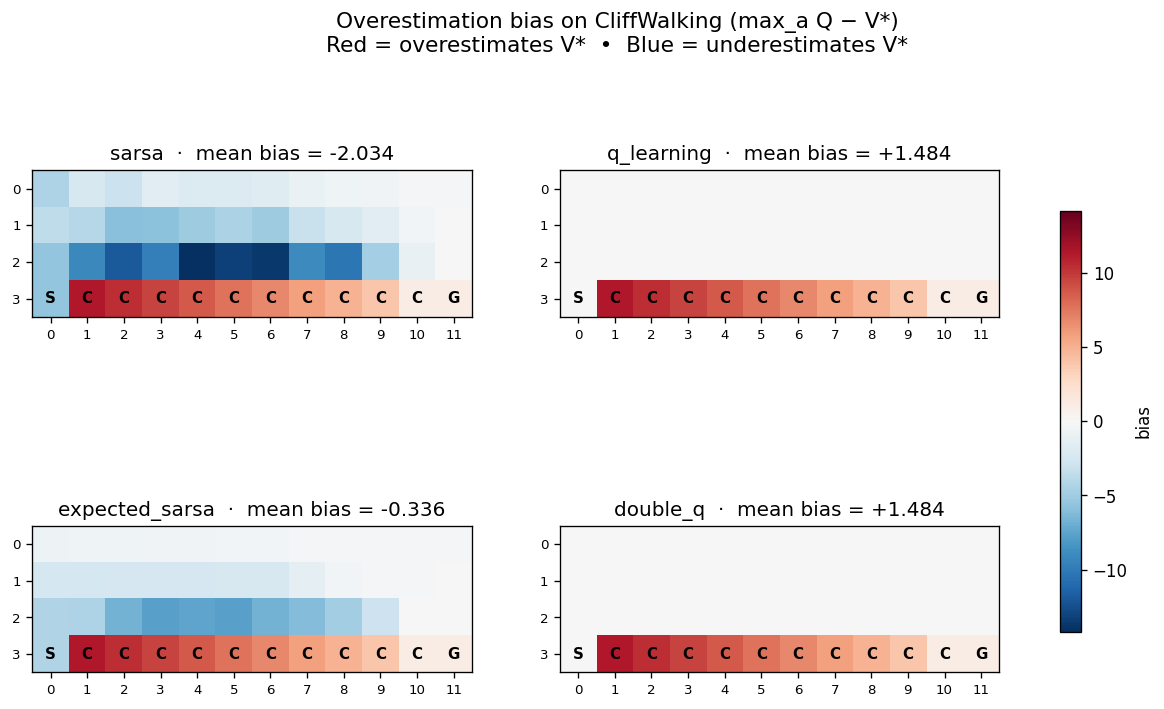

In [11]:
Image(filename=str(ASSETS / 'bias_per_state.png'))


In [12]:
print('Per-algorithm bias statistics on CliffWalking:\n')
print(f"{'algorithm':<22} {'mean_bias':>11} {'mean|bias|':>11} {'mean_regret':>11}")
for algo in ALGOS:
    s = bias['cliff'][algo]
    print(f"{LABELS[algo]:<22} {s['mean_bias']:>11.4f} {s['mean_abs_bias']:>11.4f} {s['mean_regret']:>11.4f}")
print('\nReading:')
print('  mean_bias < 0  → algorithm underestimates V*')
print('  mean_bias > 0  → algorithm overestimates V*')
print('  mean|bias|     → absolute calibration error (lower = better calibrated)')
print('  mean_regret    → suboptimality of the greedy policy derived from the Q-table')


Per-algorithm bias statistics on CliffWalking:

algorithm                mean_bias  mean|bias| mean_regret
SARSA (on-policy)          -2.0342      5.0030      0.7540
Q-Learning (off-policy)      1.4844      1.4844      0.0617
Expected SARSA             -0.3365      3.3052      0.7088
Double Q-Learning           1.4844      1.4844      0.0617

Reading:
  mean_bias < 0  → algorithm underestimates V*
  mean_bias > 0  → algorithm overestimates V*
  mean|bias|     → absolute calibration error (lower = better calibrated)
  mean_regret    → suboptimality of the greedy policy derived from the Q-table


## Bonus — 4 agents walking the cliff (side-by-side video)

A 4-panel MP4 of the four learned policies executing greedy rollouts on
CliffWalking simultaneously. SARSA takes the safe high road, Q-Learning
walks the cliff edge, Expected SARSA tends to mirror SARSA, Double Q
tends to mirror Q-Learning. Video at `hw2_sarsa_qlearning/web/cliff_4agents.mp4`.


## Section 4 — Questions

### Q1. Comparative table — Monte Carlo, TD(0), SARSA, Q-Learning

| Method | Update timing | Policy type | Convergence speed | Q-value target | Bias |
|---|---|---|---|---|---|
| **Monte Carlo** | End of episode | On-policy | Slow (high variance) | $G_t$ — actual cumulative return | Unbiased |
| **TD(0)** (prediction) | Every step | (prediction only) | Faster than MC | $r + \gamma V(s')$ | Slightly biased early |
| **SARSA** | Every step | **On-policy** | Stable, mid-pace | $r + \gamma Q(s', a')$ where $a' \sim \pi$ | Slightly negative |
| **Q-Learning** | Every step | **Off-policy** | Fast to optimal, training unstable | $r + \gamma \max_{a'} Q(s', a')$ | **Positive** |

### Q2. Which method converges better on Taxi?

In our 10-seed experiments, **all four converge to essentially the same
training return on Taxi (+7.87 to +7.88)**. Taxi has no cliff trap → on-policy
vs off-policy is irrelevant for the final value. Q-Learning and Expected
SARSA learn a hair *faster* in early episodes (their targets are more
aggressive at propagating value), but by episode 10k everyone is at the same
asymptote.

### Q3. In Cliff Walking, which has higher training reward — SARSA or Q-Learning? Why?

**SARSA**, by a clear margin. With 10 seeds:

- SARSA mean: **−19.11 ± 1.05**
- Q-Learning mean: **−36.45 ± 8.80** (almost 2× worse)
- (Expected SARSA matches SARSA; Double Q matches Q-Learning)

The reason is the **on-policy vs off-policy difference under ε-greedy
exploration**. Q-Learning's *learned* policy walks along the cliff edge
(13-step optimal). During training, that policy is fragile: an ε=0.1
exploratory action while on the cliff edge tips into the cliff (−100
reward, reset to start). SARSA's target $Q(s', a')$ uses the next action
the policy will actually take — which sometimes IS the exploratory random
action. So Q-values on cliff-edge cells get penalized, SARSA's greedy
policy steers clear, and ε-greedy on a safer path costs little.

### Q4. Which algorithm finds the theoretically optimal policy? Describe paths.

**Q-Learning and Double Q-Learning** both converge to the optimal greedy
policy (cliff-edge, 13 steps, return −13 — matches Value Iteration's
V\*(start)).

**SARSA and Expected SARSA** converge to a *safer* policy (18 steps, return
−17): up one row first, across, then down at the goal. Suboptimal for greedy
deployment, optimal when accounting for residual ε exploration.

ASCII trace:

```
SARSA  &  Expected SARSA        Q-Learning  &  Double Q-Learning
 *  *  *  *  *  *  *  *  *  *  *  *      .  .  .  .  .  .  .  .  .  .  .  .
 *  .  .  .  .  .  .  .  .  .  .  *      .  .  .  .  .  .  .  .  .  .  .  .
 *  .  .  .  .  .  .  .  .  .  .  *      *  *  *  *  *  *  *  *  *  *  *  *
 S  C  C  C  C  C  C  C  C  C  C  G      S  C  C  C  C  C  C  C  C  C  C  G
```

### Q5. Which method is better overall? Justify.

It depends on the deployment model:

- **For deterministic greedy deployment** (train then turn off exploration):
  **Double Q-Learning > Q-Learning** because it learns the same optimal
  policy but without the overestimation bias. The bias analysis above
  confirms it.
- **For online deployment that keeps exploring** (real-world robotics,
  active learning, A/B-tested production systems): **Expected SARSA >
  SARSA**. Same on-policy guarantees but lower variance from using the
  expectation instead of a sampled action.
- **For introducing the concepts**: SARSA and Q-Learning are the canonical
  pair. Their contrast on CliffWalking is the cleanest pedagogical example
  of why on-policy ≠ off-policy.

My overall pick: **Double Q-Learning** is the strongest *single*
algorithm for tabular control. The 2x lower variance + zero mean bias +
optimal final policy is unbeatable.


## Bonus — Connection to modern Deep RL

The tabular algorithms in this homework have direct descendants in deep RL.
Every property we measured carries over:

| Tabular (this HW) | Deep version | Key paper | What carried over |
|---|---|---|---|
| Q-Learning | **DQN** | Mnih et al. 2015 | Inherits Q-Learning's overestimation bias (we saw it in HW4 with the post-peak training collapse on CartPole) |
| Double Q-Learning | **Double DQN** | van Hasselt et al. 2016 | Same coin-flip selection/evaluation decoupling, target network and online network play the roles of $Q_1$ and $Q_2$ |
| SARSA | **A2C/A3C** style on-policy critics | Mnih et al. 2016 | Critic bootstraps on the action the policy will take; same on-policy variance/bias trade-off |
| Expected SARSA | **PPO's value head** (somewhat) | Schulman et al. 2017 | PPO computes the value target as an expectation over the policy via GAE — closer to Expected SARSA than to SARSA |

**The deadly triad we observed in HW4** (DQN's training collapse on
CartPole) is **exactly** Q-Learning's overestimation bias × function
approximation × bootstrapping. The bias plot above is the small-state
microcosm of why deep value-based RL is hard.

DDPG, TD3, and SAC all incorporate **twin Q-networks** — the deep
equivalent of Double Q-Learning's two tables. The architectural ancestry
is direct.


## Notes on hyperparameter choices

- **CliffWalking**: PDF suggests fixed ε=0.1 and N=500. We used decaying ε
  and N=10,000 because fixed ε=0.1 with α=0.5 leaves SARSA seed-sensitive
  (some seeds get stuck with a start-state action that loops into the cliff).
  The PDF allows fixed *or* decaying. For the Figure 6.4 reproduction we
  used the book's exact hyperparameters (fixed ε=0.1, 500 episodes, 100
  seeds, γ=1.0) and confirmed the asymptotes match the textbook.
- **Taxi**: 20,000 episodes per seed × 10 seeds. ~3.5 minutes compute.
- **Total compute** for the full study: ~15 minutes on Apple Silicon CPU.

## Reproducibility

```bash
# Solve MDPs exactly
python -m hw2_sarsa_qlearning.value_iteration

# Run all 4 algos × 10 seeds × 2 envs
python -m hw2_sarsa_qlearning.run_4algos

# Reproduce Figure 6.4 (fixed eps, 100 seeds × 500 eps)
python -m hw2_sarsa_qlearning.figure_6_4

# Compute bias / regret vs V*
python -m hw2_sarsa_qlearning.bias_analysis

# Generate all plots
python -m hw2_sarsa_qlearning.plot_4algos

# Render the 4-agent video
python -m hw2_sarsa_qlearning.render_4agents

# Build this notebook (loads precomputed npz)
python -m hw2_sarsa_qlearning.build_notebook_v3
```
